# Neural Mechanics V2 — Data Preparation & Preliminary Analysis
**Iteration 5:** 5-min intervals · 150 emp + 150 unemp · median + 90% CI  
**Date range:** Jan 6 – Mar 1, 2020 (8 full weeks, 56 days)  
**Project:** CS 7180 Neural Mechanics — Mobility Pattern Detection via LLM Probing

---
### Experiment Summary

| Exp | Task | Users | Days | Hist Days | Context Window |
|-----|------|-------|------|-----------|----------------|
| 1a | Weekday vs Weekend | 150 employed | All days | 22 (11wkday+11wkend) | 5am–8:30am |
| 1b | 5-class Day-of-Week | 150 employed | Weekdays | 15 (3/class×5) | 1pm–5pm |
| 2 | Employed vs Unemployed | 300 (150+150) | Workdays | 22 workdays | 5am–8:30am |

In [5]:
import pandas as pd

df = pd.read_csv("./data/trajectories_processed.csv")  # 改成你的真实文件名

# 1️⃣ 总用户数
total_users = df["cuebiq_id"].nunique()

# 2️⃣ employed 用户数
unique_employed_users = df[df["is_employed"] == 1]["cuebiq_id"].nunique()

# 3️⃣ 比例
ratio = unique_employed_users / total_users

print("Total unique users:", total_users)
print("Unique employed users:", unique_employed_users)
print("Employed ratio:", ratio)

Total unique users: 240
Unique employed users: 120
Employed ratio: 0.5


## Section A: Configuration

In [3]:
# === A1: Configuration ===
CONFIG = {
    # Date range (8 full weeks: Mon Jan 6 – Sun Mar 1)
    'date_start': '2020-01-06',
    'date_end': '2020-03-01',
    'holidays': ['2020-01-20', '2020-02-17'],  # MLK Day, Presidents Day

    # User sampling
    'n_employed': 150,
    'n_unemployed': 150,
    'min_pings_threshold': 5000,
    'seed': 42,
    'oversample_factor': 5,  # Query 3x users, then filter down

    # Historical context config (reference for pipeline — not used in this notebook)
    # Exp1a: 22 days = 11 non-holiday weekdays + 11 weekends
    # Exp1b: 15 days = 3 per weekday class (Mon/Tue/Wed/Thu/Fri)
    # Exp2:  22 days = 22 non-holiday weekdays
    'hist_config': {
        'exp1a': {'n_weekdays': 11, 'n_weekends': 11, 'total': 22},
        'exp1b': {'n_per_class': 4, 'total': 20},
        'exp2':  {'n_workdays': 22, 'total': 22},
    },

    # User qualification thresholds (guarantees no user dropped in pipeline)
    'qual': {
        'min_weekend_morning':          12,  # 11 hist + 1 target
        'min_nonhol_weekday_morning':   23,  # 22 hist(exp2) + 1 target
        'min_per_wkday_class_afternoon': 5,  # 4 hist + 1 target (exp1b)
        'min_morning_active_frac':     0.60, # ≥80% of morning-data days show movement
        'min_afternoon_active_frac':   0.60, # ≥80% of afternoon-data days show movement
    },

    # File paths
    'data_dir': './data',
    'users_file': './data/users.csv',
    'traj_5min_file': './data/trajectories_5min.csv',
    'traj_processed_file': './data/trajectories_processed.csv',
    'coords_file': './data/trajectories_with_coords.csv',
}
print("Config loaded. Date range:", CONFIG['date_start'], "to", CONFIG['date_end'])

Config loaded. Date range: 2020-01-06 to 2020-03-01


In [1]:
# === A2: Imports ===
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery

# warnings.filterwarnings('ignore')
# os.makedirs(CONFIG['data_dir'], exist_ok=True)
# client = bigquery.Client(project='epistorm-mobility')
# print("BigQuery client initialized")

## Section B: BigQuery Data Acquisition
> **Run once**, then skip to Section C for subsequent runs.

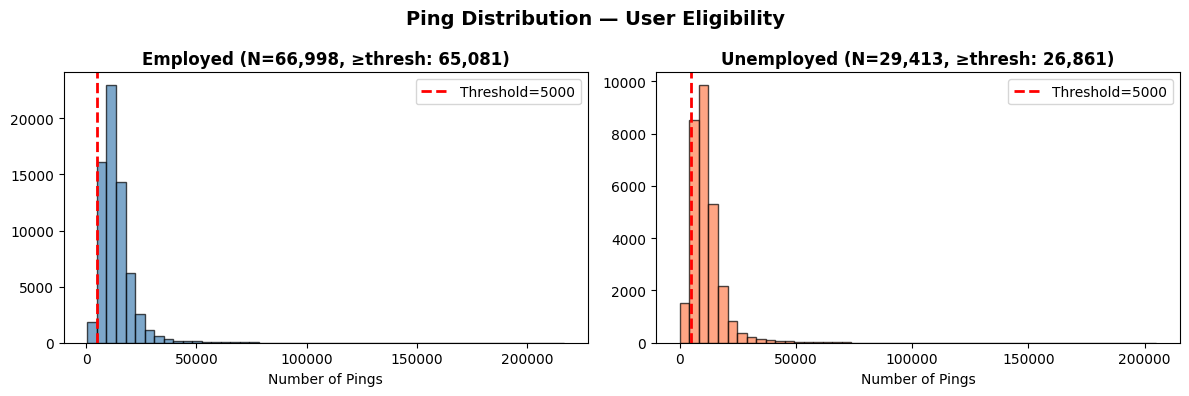

In [3]:
# === B1: Ping distribution & eligible user pool ===
ping_dist = client.query("""
    SELECT cuebiq_id, num_pings,
           CASE WHEN work_geopoint IS NOT NULL THEN 1 ELSE 0 END as is_employed
    FROM `epistorm-mobility.neural_mechanics.boston_csa_home_users`
""").to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (emp, title) in enumerate([(1, 'Employed'), (0, 'Unemployed')]):
    subset = ping_dist[ping_dist['is_employed'] == emp]['num_pings']
    axes[i].hist(subset, bins=50, edgecolor='black', alpha=0.7,
                 color='steelblue' if emp else 'coral')
    axes[i].axvline(CONFIG['min_pings_threshold'], color='r', ls='--', lw=2,
                    label=f"Threshold={CONFIG['min_pings_threshold']}")
    n_above = (subset >= CONFIG['min_pings_threshold']).sum()
    axes[i].set_title(f'{title} (N={len(subset):,}, ≥thresh: {n_above:,})', fontweight='bold')
    axes[i].set_xlabel('Number of Pings')
    axes[i].legend()
plt.suptitle('Ping Distribution — User Eligibility', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/ping_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# === B2: Query eligible users (oversample pool) ===
np.random.seed(CONFIG['seed'])
eligible = client.query(f"""
    SELECT cuebiq_id, num_pings,
           CASE WHEN work_geopoint IS NOT NULL THEN 1 ELSE 0 END as is_employed,
           ST_Y(home_geopoint) as home_lat, ST_X(home_geopoint) as home_lng,
           home_geo_id
    FROM `epistorm-mobility.neural_mechanics.boston_csa_home_users`
    WHERE num_pings >= {CONFIG['min_pings_threshold']}
""").to_dataframe()

n_pool = CONFIG['oversample_factor'] * max(CONFIG['n_employed'], CONFIG['n_unemployed'])
emp_pool = eligible[eligible['is_employed'] == 1].sample(n=min(n_pool, len(eligible[eligible['is_employed']==1])),
                                                          random_state=CONFIG['seed'])
unemp_pool = eligible[eligible['is_employed'] == 0].sample(n=min(n_pool, len(eligible[eligible['is_employed']==0])),
                                                            random_state=CONFIG['seed'])
user_pool = pd.concat([emp_pool, unemp_pool], ignore_index=True)
print(f"Eligible: {len(eligible):,} (Emp={len(eligible[eligible['is_employed']==1]):,}, "
      f"Unemp={len(eligible[eligible['is_employed']==0]):,})")
print(f"Oversample pool: {len(user_pool)} (Emp={len(emp_pool)}, Unemp={len(unemp_pool)})")

Eligible: 91,942 (Emp=65,081, Unemp=26,861)
Oversample pool: 1500 (Emp=750, Unemp=750)


In [5]:
# === B3: Query 5-minute trajectories for pool ===
user_list = ",".join([f"'{u}'" for u in user_pool['cuebiq_id']])

query_5min = f"""
WITH five_min_visits AS (
    SELECT cuebiq_id, DATE(ts_local) as date,
           EXTRACT(HOUR FROM ts_local) as hour,
           CAST(FLOOR(EXTRACT(MINUTE FROM ts_local) / 5) * 5 AS INT64) as min5,
           EXTRACT(DAYOFWEEK FROM ts_local) as dow,
           geo_id, COUNT(*) as cnt
    FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`
    WHERE DATE(ts_local) BETWEEN '{CONFIG['date_start']}' AND '{CONFIG['date_end']}'
      AND cuebiq_id IN ({user_list})
    GROUP BY cuebiq_id, date, hour, min5, dow, geo_id
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (
        PARTITION BY cuebiq_id, date, hour, min5 ORDER BY cnt DESC
    ) as rn
    FROM five_min_visits
)
SELECT cuebiq_id, date, hour, min5, dow, geo_id
FROM ranked WHERE rn = 1
ORDER BY cuebiq_id, date, hour, min5
"""
print("Querying 5-min trajectories (may take several minutes)...")
df_traj_pool = client.query(query_5min).to_dataframe()
df_traj_pool['date'] = df_traj_pool['date'].astype(str)
df_traj_pool['time_slot'] = df_traj_pool['hour'].apply(lambda h: f"{h:02d}") + ':' + \
                             df_traj_pool['min5'].apply(lambda m: f"{m:02d}")
print(f"Retrieved {len(df_traj_pool):,} rows for {df_traj_pool['cuebiq_id'].nunique()} users")

# Save pool data temporarily
user_pool.to_csv(f"{CONFIG['data_dir']}/users_pool.csv", index=False)
df_traj_pool.to_csv(f"{CONFIG['data_dir']}/trajectories_5min_pool.csv", index=False)
print("Pool data saved to CSV")

Querying 5-min trajectories (may take several minutes)...
Retrieved 7,640,609 rows for 1500 users
Pool data saved to CSV


## Section C: Load from Local CSV
> **Start here** after first BQ run.

In [6]:
# === C1: Load pool data from CSV ===
user_pool = pd.read_csv(f"{CONFIG['data_dir']}/users_pool.csv")
df_traj_pool = pd.read_csv(f"{CONFIG['data_dir']}/trajectories_5min_pool.csv")
df_traj_pool['date'] = df_traj_pool['date'].astype(str)
if 'time_slot' not in df_traj_pool.columns:
    df_traj_pool['time_slot'] = (df_traj_pool['hour'].apply(lambda h: f"{h:02d}") + ':' +
                                  df_traj_pool['min5'].apply(lambda m: f"{m:02d}"))
print(f"Loaded pool: {len(user_pool)} users, {len(df_traj_pool):,} trajectory rows")

Loaded pool: 1500 users, 7,640,609 trajectory rows


## Section D: User Qualification & Filtering
Ensure every selected user can supply enough days for **all 3 experiments**,
so no user is dropped in the downstream pipeline.

In [7]:
# === D1: Add labels to pool trajectories ===
home_lookup = user_pool.set_index('cuebiq_id')['home_geo_id'].to_dict()
emp_lookup = user_pool.set_index('cuebiq_id')['is_employed'].to_dict()

df = df_traj_pool.copy()
df['home_geo_id'] = df['cuebiq_id'].map(home_lookup)
df['is_employed'] = df['cuebiq_id'].map(emp_lookup)
df['is_at_home'] = (df['geo_id'] == df['home_geo_id']).astype(int)
df['is_weekend'] = df['dow'].isin([1, 7]).astype(int)      # Sun=1, Sat=7
df['is_weekday'] = 1 - df['is_weekend']
df['is_holiday'] = df['date'].isin(CONFIG['holidays']).astype(int)
df['is_nonhol_weekday'] = ((df['is_weekday'] == 1) & (df['is_holiday'] == 0)).astype(int)

# Day-of-week class (Mon=0..Fri=4 for weekdays; BQ: Mon=2..Fri=6)
dow_to_class = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4}  # Mon=0, Tue=1, Wed=2, Thu=3, Fri=4
df['wkday_class'] = df['dow'].map(dow_to_class)   # NaN for weekends

# Time windows
df['in_morning'] = ((df['hour'] * 60 + df['min5']) >= 300) & \
                    ((df['hour'] * 60 + df['min5']) <= 510)   # 5:00–8:30
df['in_afternoon'] = ((df['hour'] * 60 + df['min5']) >= 780) & \
                      ((df['hour'] * 60 + df['min5']) <= 1020) # 1:00–5:00pm (13*60=780, 17*60=1020)
print(f"Labels added. Morning slots: {df['in_morning'].sum():,}, Afternoon slots: {df['in_afternoon'].sum():,}")

Labels added. Morning slots: 1,079,377, Afternoon slots: 1,561,667


In [8]:
# === D2: Compute per-user qualification metrics ===
qual = CONFIG['qual']
user_ids = df['cuebiq_id'].unique()
metrics = []

for uid in user_ids:
    u = df[df['cuebiq_id'] == uid]

    # --- Days with data in each window ---
    # Weekend days with morning data
    wkend_morn = u[(u['is_weekend'] == 1) & u['in_morning']]['date'].nunique()
    # Non-holiday weekday days with morning data
    nhwd_morn = u[(u['is_nonhol_weekday'] == 1) & u['in_morning']]['date'].nunique()
    # Per weekday class: non-holiday days with afternoon data
    class_aft = {}
    for c in range(5):
        class_aft[c] = u[(u['wkday_class'] == c) & (u['is_holiday'] == 0) &
                         u['in_afternoon']]['date'].nunique()
    min_class_aft = min(class_aft.values())

    # --- Morning activity: fraction of morning-data days with movement ---
    morn_data = u[u['in_morning']].groupby('date')['is_at_home'].agg(['count', 'min'])
    # 'min'==0 means at least one slot was away from home
    n_morn_days = len(morn_data)
    n_morn_active = (morn_data['min'] == 0).sum()
    morn_active_frac = n_morn_active / n_morn_days if n_morn_days > 0 else 0

    # --- Afternoon activity: fraction of afternoon-data days with movement ---
    aft_data = u[u['in_afternoon']].groupby('date')['is_at_home'].agg(['count', 'min'])
    n_aft_days = len(aft_data)
    n_aft_active = (aft_data['min'] == 0).sum()
    aft_active_frac = n_aft_active / n_aft_days if n_aft_days > 0 else 0

    metrics.append({
        'cuebiq_id': uid,
        'is_employed': emp_lookup.get(uid, -1),
        'total_days': u['date'].nunique(),
        'wkend_morning_days': wkend_morn,
        'nhwd_morning_days': nhwd_morn,
        'min_wkday_class_aft': min_class_aft,
        'morning_active_frac': morn_active_frac,
        'afternoon_active_frac': aft_active_frac,
        **{f'class_{c}_aft': class_aft[c] for c in range(5)},
    })

metrics_df = pd.DataFrame(metrics)
print(f"Computed metrics for {len(metrics_df)} users")
metrics_df[['wkend_morning_days', 'nhwd_morning_days', 'min_wkday_class_aft',
            'morning_active_frac', 'afternoon_active_frac']].describe().round(2)

Computed metrics for 1500 users


,wkend_morning_days,nhwd_morning_days,min_wkday_class_aft,morning_active_frac,afternoon_active_frac
count,1500.00,1500.00,1500.00,1500.00,1500.00
mean,14.81,36.21,5.80,0.47,0.77
std,2.22,3.53,0.56,0.28,0.20
min,0.00,4.00,0.00,0.00,0.00
25%,14.00,36.00,6.00,0.21,0.66
50%,16.00,38.00,6.00,0.54,0.83
75%,16.00,38.00,6.00,0.70,0.92
max,16.00,38.00,6.00,1.00,1.00


In [9]:

# === D3: Apply qualification filter (different criteria for emp vs unemp) ===
q = CONFIG['qual']

# Employed: need day counts + activity rates (they should be commuting)
emp_mask = (
    (metrics_df['is_employed'] == 1) &
    (metrics_df['wkend_morning_days']  >= q['min_weekend_morning']) &
    (metrics_df['nhwd_morning_days']   >= q['min_nonhol_weekday_morning']) &
    (metrics_df['min_wkday_class_aft'] >= q['min_per_wkday_class_afternoon']) &
    (metrics_df['morning_active_frac'] >= q['min_morning_active_frac']) &
    (metrics_df['afternoon_active_frac'] >= q['min_afternoon_active_frac'])
)

# Unemployed: need day counts only (staying home IS their signal, not a data flaw)
unemp_mask = (
    (metrics_df['is_employed'] == 0) &
    (metrics_df['wkend_morning_days']  >= q['min_weekend_morning']) &
    (metrics_df['nhwd_morning_days']   >= q['min_nonhol_weekday_morning']) &
    (metrics_df['min_wkday_class_aft'] >= q['min_per_wkday_class_afternoon'])
)

qualified = metrics_df[emp_mask | unemp_mask].copy()
n_q_emp = (qualified['is_employed'] == 1).sum()
n_q_unemp = (qualified['is_employed'] == 0).sum()

print(f"Qualification results:")
print(f"  Pool:      {len(metrics_df)} users")
print(f"  Qualified: {len(qualified)} users ({len(qualified)/len(metrics_df)*100:.0f}%)")
print(f"    Employed:   {n_q_emp} (filtered by days + activity)")
print(f"    Unemployed: {n_q_unemp} (filtered by days only)")

assert n_q_emp >= CONFIG['n_employed'], \
    f"Not enough qualified employed ({n_q_emp} < {CONFIG['n_employed']}). Lower thresholds or increase pool."
assert n_q_unemp >= CONFIG['n_unemployed'], \
    f"Not enough qualified unemployed ({n_q_unemp} < {CONFIG['n_unemployed']}). Lower thresholds or increase pool."
print("\n✓ Sufficient qualified users for 150+150 sampling")

Qualification results:
  Pool:      1500 users
  Qualified: 1099 users (73%)
    Employed:   429 (filtered by days + activity)
    Unemployed: 670 (filtered by days only)

✓ Sufficient qualified users for 150+150 sampling


## Section E: Balanced Sampling (150 + 150)

In [10]:
# === E1: Sample 150 employed + 150 unemployed from qualified pool ===
np.random.seed(CONFIG['seed'])

selected_emp = qualified[qualified['is_employed'] == 1].sample(
    n=CONFIG['n_employed'], random_state=CONFIG['seed'])
selected_unemp = qualified[qualified['is_employed'] == 0].sample(
    n=CONFIG['n_unemployed'], random_state=CONFIG['seed'])
selected_ids = set(selected_emp['cuebiq_id']).union(set(selected_unemp['cuebiq_id']))

# Build final users DataFrame from original user_pool metadata
all_sampled = user_pool[user_pool['cuebiq_id'].isin(selected_ids)].copy()
all_sampled['in_exp1'] = all_sampled['is_employed'].astype(bool)  # 150 employed
all_sampled['in_exp2'] = True                                      # all 300

print(f"Final sample: {len(all_sampled)} users")
print(f"  Exp1 (employed only): {all_sampled['in_exp1'].sum()}")
print(f"  Exp2 (all):           {all_sampled['in_exp2'].sum()}")

# Trim trajectories to selected users only
df_final = df_traj_pool[df_traj_pool['cuebiq_id'].isin(selected_ids)].copy()
print(f"  Trajectory rows: {len(df_final):,}")

# Save
all_sampled.to_csv(CONFIG['users_file'], index=False)
df_final.to_csv(CONFIG['traj_5min_file'], index=False)
print(f"\n✓ Saved {CONFIG['users_file']} and {CONFIG['traj_5min_file']}")

Final sample: 300 users
  Exp1 (employed only): 150
  Exp2 (all):           300
  Trajectory rows: 1,550,195

✓ Saved ./data/users.csv and ./data/trajectories_5min.csv


## Section F: Build 5-Minute Grid from Raw Pings

**Forward fill method:** For each user-day, create a regular 5-min grid (00:00–23:55, 288 slots).
At each grid point, geo_id = the **most recent GPS ping at or before** that time.
If no ping exists before a grid point, user is assumed at home.

This ensures **every user has exactly 288 rows per day** — uniform, no gaps.

In [11]:
# === F1: Query raw pings for final 300 users (run once, then skip to F2) ===
all_sampled = pd.read_csv(CONFIG['users_file'])
RAW_FILE = f"{CONFIG['data_dir']}/raw_pings_300.csv"

if os.path.exists(RAW_FILE):
    print(f"Raw pings already cached: {RAW_FILE}")
else:
    user_list = ",".join([f"'{u}'" for u in all_sampled['cuebiq_id']])
    query_raw = f"""
    WITH deduped AS (
        SELECT cuebiq_id,
               DATE(ts_local) as date,
               EXTRACT(DAYOFWEEK FROM ts_local) as dow,
               EXTRACT(HOUR FROM ts_local) * 60 + EXTRACT(MINUTE FROM ts_local) as minutes,
               geo_id,
               ROW_NUMBER() OVER (
                   PARTITION BY cuebiq_id, DATE(ts_local),
                                EXTRACT(HOUR FROM ts_local) * 60 + EXTRACT(MINUTE FROM ts_local)
                   ORDER BY ts_local DESC
               ) as rn
        FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`
        WHERE DATE(ts_local) BETWEEN '{CONFIG['date_start']}' AND '{CONFIG['date_end']}'
          AND cuebiq_id IN ({user_list})
    )
    SELECT cuebiq_id, date, dow, minutes, geo_id
    FROM deduped WHERE rn = 1
    ORDER BY cuebiq_id, date, minutes
    """
    print("Querying raw pings for 300 users (partition+cluster pruned)...")
    df_raw = client.query(query_raw).to_dataframe()
    df_raw['date'] = df_raw['date'].astype(str)
    df_raw.to_csv(RAW_FILE, index=False)
    print(f"Saved {len(df_raw):,} raw pings to {RAW_FILE}")

Querying raw pings for 300 users (partition+cluster pruned)...
Saved 2,443,057 raw pings to ./data/raw_pings_300.csv


In [12]:
# === F2: Load raw pings from CSV (start here after first query) ===
all_sampled = pd.read_csv(CONFIG['users_file'])
RAW_FILE = f"{CONFIG['data_dir']}/raw_pings_300.csv"
df_raw = pd.read_csv(RAW_FILE)
df_raw['date'] = df_raw['date'].astype(str)
print(f"Loaded {len(df_raw):,} raw pings for {df_raw['cuebiq_id'].nunique()} users")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"Median pings per user-day: {df_raw.groupby(['cuebiq_id','date']).size().median():.0f}")

Loaded 2,443,057 raw pings for 300 users
Date range: 2020-01-06 to 2020-03-01
Median pings per user-day: 134


In [13]:
# === F3: Build complete 5-min grid with forward fill ===

def forward_fill_grid(ping_minutes, ping_geos, home_geo, grid_minutes):
    """
    Map raw pings onto a regular 5-min grid via forward fill.

    At each grid point t, geo_id = most recent ping at or before t.
    If no ping before t, default to home_geo.

    Example:
        Raw pings:  7:00->A, 7:02->A, 7:07->B, 7:09->B
        Grid:       7:00->A, 7:05->A (from 7:02), 7:10->B (from 7:09), 7:15->B (still)
    """
    result = []
    j = 0
    last_geo = home_geo
    for m in grid_minutes:
        while j < len(ping_minutes) and ping_minutes[j] <= m:
            last_geo = ping_geos[j]
            j += 1
        result.append(last_geo)
    return result

# Grid: every 5 min, full day (288 slots)
GRID_MINUTES = np.arange(0, 24 * 60, 5)
N_SLOTS = len(GRID_MINUTES)
GRID_HOURS = GRID_MINUTES // 60
GRID_MIN5S = GRID_MINUTES % 60

# Lookups
home_lookup = all_sampled.set_index('cuebiq_id')['home_geo_id'].to_dict()
users = all_sampled['cuebiq_id'].unique()
all_dates = sorted(df_raw['date'].unique())

print(f"Building grids: {len(users)} users x {len(all_dates)} dates x {N_SLOTS} slots/day")
print(f"Expected rows: {len(users) * len(all_dates) * N_SLOTS:,}")

frames = []
for i, uid in enumerate(users):
    if i % 50 == 0:
        print(f"  User {i+1}/{len(users)}...")
    home_geo = home_lookup[uid]
    user_pings = df_raw[df_raw['cuebiq_id'] == uid]

    user_geos = []
    for date in all_dates:
        day = user_pings[user_pings['date'] == date].sort_values('minutes')
        if len(day) > 0:
            geos = forward_fill_grid(day['minutes'].values, day['geo_id'].values,
                                     home_geo, GRID_MINUTES)
        else:
            geos = [home_geo] * N_SLOTS
        user_geos.extend(geos)

    frames.append(pd.DataFrame({
        'cuebiq_id': uid,
        'date': np.repeat(all_dates, N_SLOTS),
        'hour': np.tile(GRID_HOURS, len(all_dates)),
        'min5': np.tile(GRID_MIN5S, len(all_dates)),
        'geo_id': user_geos,
    }))

df_grid = pd.concat(frames, ignore_index=True)
print(f"\nGrid built: {len(df_grid):,} rows")

# Verify uniform shape
rows_per_ud = df_grid.groupby(['cuebiq_id', 'date']).size()
assert rows_per_ud.min() == N_SLOTS and rows_per_ud.max() == N_SLOTS, \
    f"Grid not uniform! min={rows_per_ud.min()}, max={rows_per_ud.max()}"
print(f"Every user-day has exactly {N_SLOTS} rows (verified)")

Building grids: 300 users x 56 dates x 288 slots/day
Expected rows: 4,838,400
  User 1/300...
  User 51/300...
  User 101/300...
  User 151/300...
  User 201/300...
  User 251/300...

Grid built: 4,838,400 rows
Every user-day has exactly 288 rows (verified)


In [26]:
# Check: how many user-days have zero pings?
pings_per_ud = df_raw.groupby(['cuebiq_id', 'date']).size()
total_ud = len(all_sampled) * len(all_dates)
has_pings = len(pings_per_ud)
zero_days = total_ud - has_pings
print(f"Total user-days: {total_ud:,}")
print(f"With pings: {has_pings:,} ({has_pings/total_ud*100:.1f}%)")
print(f"Zero pings: {zero_days:,} ({zero_days/total_ud*100:.1f}%) → will be filled with home_geo_id")

Total user-days: 16,800
With pings: 16,591 (98.8%)
Zero pings: 209 (1.2%) → will be filled with home_geo_id


In [17]:
# === F4: Add labels and save ===
user_info = all_sampled.set_index('cuebiq_id')
emp_lookup = user_info['is_employed'].to_dict()
in_exp1_lookup = user_info.get('in_exp1', user_info['is_employed'].astype(bool)).to_dict()

df_traj = df_grid.copy()
df_traj['time_slot'] = df_traj['hour'].apply(lambda h: f"{h:02d}") + ':' + \
                        df_traj['min5'].apply(lambda m: f"{m:02d}")

# Day-of-week (BQ convention: 1=Sun, 2=Mon, ..., 7=Sat)
# pandas dayofweek: Mon=0..Sun=6 → BQ convention: Sun=1,Mon=2..Sat=7
_pdow = pd.to_datetime(df_traj['date']).dt.dayofweek
df_traj['dow'] = _pdow.map({0:2, 1:3, 2:4, 3:5, 4:6, 5:7, 6:1})
#df_traj['dow'] = pd.to_datetime(df_traj['date']).dt.isoweekday() % 7 + 1

df_traj['is_employed'] = df_traj['cuebiq_id'].map(emp_lookup)
df_traj['home_geo_id'] = df_traj['cuebiq_id'].map(home_lookup)
df_traj['is_at_home'] = (df_traj['geo_id'] == df_traj['home_geo_id']).astype(int)
df_traj['is_weekend'] = df_traj['dow'].isin([1, 7]).astype(int)
df_traj['is_weekday'] = 1 - df_traj['is_weekend']
df_traj['is_holiday'] = df_traj['date'].isin(CONFIG['holidays']).astype(int)
df_traj['is_nonhol_weekday'] = ((df_traj['is_weekday'] == 1) & (df_traj['is_holiday'] == 0)).astype(int)
df_traj['in_exp1'] = df_traj['cuebiq_id'].map(in_exp1_lookup).fillna(False).astype(bool)
df_traj['in_exp2'] = True

DOW_NAMES = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
df_traj['day_name'] = df_traj['dow'].map(DOW_NAMES)
dow_class = {2:0, 3:1, 4:2, 5:3, 6:4}
df_traj['wkday_class'] = df_traj['dow'].map(dow_class)
df_traj['is_monday'] = (df_traj['dow'] == 2).astype(int)

df_traj.to_csv(CONFIG['traj_processed_file'], index=False)
print(f"Saved: {CONFIG['traj_processed_file']}")
print(f"  {len(df_traj):,} rows | {df_traj['cuebiq_id'].nunique()} users | "
      f"{df_traj['date'].nunique()} dates | {N_SLOTS} slots/user-day")

Saved: ./data/trajectories_processed.csv
  4,838,400 rows | 300 users | 56 dates | 288 slots/user-day


## Section G: P(Away from Home) Plots

**Calculation (Matteo, Feb 20):** For each user at each hour, compute personal away-rate across days.
Then across users: **median** + 5th/95th percentile (90% CI). Each user counts equally.
With the uniform grid, every user has exactly 12 slots per hour per day.

In [2]:
# === G0: Plotting helpers ===
def compute_away_stats(data, group_col, group_vals, time_col='hour'):
    """Per-user-first median P(away) + 90% CI at each hour."""
    results = {}
    for val, label in group_vals:
        subset = data[data[group_col] == val]
        user_hour = (subset.groupby(['cuebiq_id', time_col])['is_at_home']
                     .mean().reset_index()
                     .rename(columns={'is_at_home': 'p_home'}))
        user_hour['p_away'] = 1 - user_hour['p_home']
        stats = (user_hour.groupby(time_col)['p_away']
                 .agg(median='median',
                      ci_lo=lambda x: np.percentile(x, 5),
                      ci_hi=lambda x: np.percentile(x, 95))
                 .reset_index())
        results[label] = stats
    return results

def compute_dist_stats(data, group_col, group_vals, time_col='hour'):
    """Per-user-first median distance + 90% CI at each hour."""
    results = {}
    for val, label in group_vals:
        subset = data[data[group_col] == val]
        user_hour = (subset.groupby(['cuebiq_id', time_col])['dist_km']
                     .median().reset_index())
        stats = (user_hour.groupby(time_col)['dist_km']
                 .agg(median='median',
                      ci_lo=lambda x: np.percentile(x, 5),
                      ci_hi=lambda x: np.percentile(x, 95))
                 .reset_index())
        results[label] = stats
    return results

print("Plotting helpers defined")

Plotting helpers defined


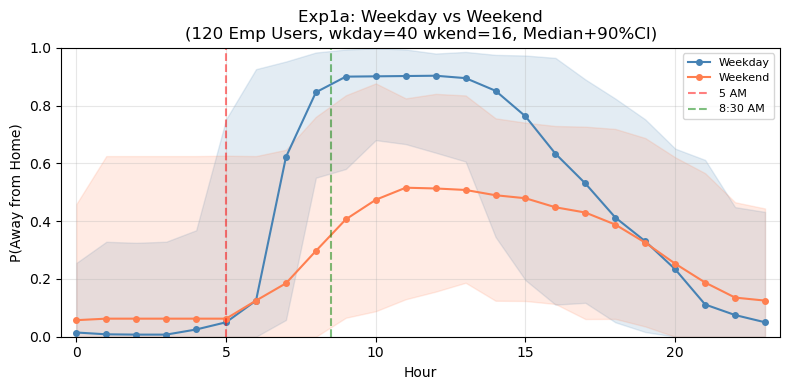

In [9]:
df_traj = pd.read_csv("./data/trajectories_processed.csv")
# === G1: Exp1a - Weekday vs Weekend (employed only, all days) ===
data_1a = df_traj[df_traj['in_exp1']]
n_u = data_1a['cuebiq_id'].nunique()
n_wd = data_1a[data_1a['is_weekday']==1]['date'].nunique()
n_we = data_1a[data_1a['is_weekend']==1]['date'].nunique()

stats = compute_away_stats(data_1a, 'is_weekday', [(1, 'Weekday'), (0, 'Weekend')])

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for label, color in [('Weekday', 'steelblue'), ('Weekend', 'coral')]:
    s = stats[label]
    ax.plot(s['hour'], s['median'], 'o-', label=label, color=color, markersize=4, linewidth=1.5)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvline(5, color='r', ls='--', alpha=0.5, label='5 AM')
ax.axvline(8.5, color='g', ls='--', alpha=0.5, label='8:30 AM')
ax.set_xlabel('Hour'); ax.set_ylabel('P(Away from Home)')
ax.set_title(f'Exp1a: Weekday vs Weekend\n({n_u} Emp Users, wkday={n_wd} wkend={n_we}, Median+90%CI)')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 23.5); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/exp1a_away_probability.png", dpi=300, bbox_inches='tight')
plt.show()

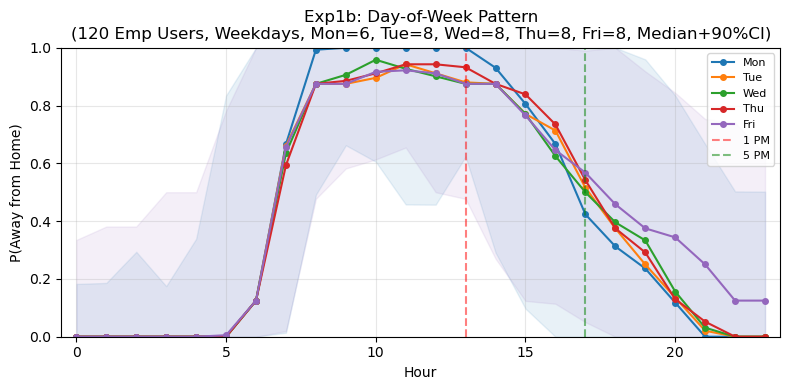

In [10]:
# === G2: Exp1b - 5-class Day-of-Week (employed only, weekdays only) ===
data_1b = df_traj[(df_traj['in_exp1']) & (df_traj['is_weekday']==1) & (df_traj['is_holiday']==0)]
n_u = data_1b['cuebiq_id'].nunique()
day_labels = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
day_counts = data_1b.groupby('wkday_class')['date'].nunique()
cnt_str = ', '.join([f"{day_labels[c]}={day_counts.get(c,0)}" for c in range(5)])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for c, color in zip(range(5), colors):
    sub = data_1b[data_1b['wkday_class'] == c]
    s = compute_away_stats(sub, 'wkday_class', [(c, day_labels[c])])[day_labels[c]]
    ax.plot(s['hour'], s['median'], 'o-', label=day_labels[c], color=color, markersize=4, linewidth=1.5)
    if day_labels[c] in ('Mon', 'Fri'):
        ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.1, color=color)

ax.axvline(13, color='r', ls='--', alpha=0.5, label='1 PM')
ax.axvline(17, color='g', ls='--', alpha=0.5, label='5 PM')
ax.set_xlabel('Hour'); ax.set_ylabel('P(Away from Home)')
ax.set_title(f'Exp1b: Day-of-Week Pattern\n({n_u} Emp Users, Weekdays, {cnt_str}, Median+90%CI)')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 23.5); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/exp1b_away_probability.png", dpi=300, bbox_inches='tight')
plt.show()

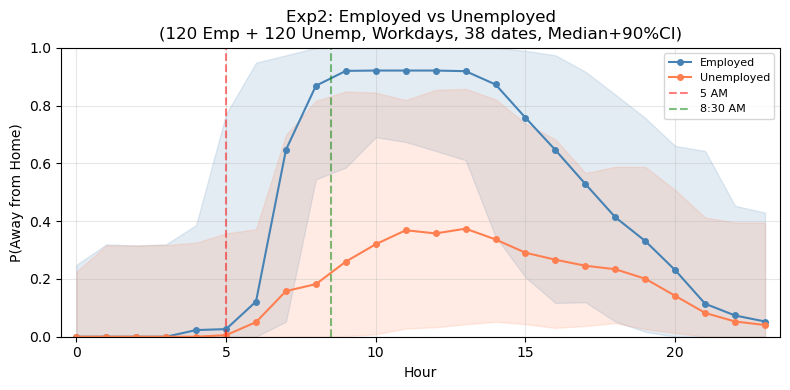

In [11]:
# === G3: Exp2 - Employed vs Unemployed (300 users, workdays only) ===
data_2 = df_traj[(df_traj['in_exp2']) & (df_traj['is_weekday']==1) & (df_traj['is_holiday']==0)]
ne = data_2[data_2['is_employed']==1]['cuebiq_id'].nunique()
nu = data_2[data_2['is_employed']==0]['cuebiq_id'].nunique()
nd = data_2['date'].nunique()

stats = compute_away_stats(data_2, 'is_employed', [(1, 'Employed'), (0, 'Unemployed')])

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for label, color in [('Employed', 'steelblue'), ('Unemployed', 'coral')]:
    s = stats[label]
    ax.plot(s['hour'], s['median'], 'o-', label=label, color=color, markersize=4, linewidth=1.5)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvline(5, color='r', ls='--', alpha=0.5, label='5 AM')
ax.axvline(8.5, color='g', ls='--', alpha=0.5, label='8:30 AM')
ax.set_xlabel('Hour'); ax.set_ylabel('P(Away from Home)')
ax.set_title(f'Exp2: Employed vs Unemployed\n({ne} Emp + {nu} Unemp, Workdays, {nd} dates, Median+90%CI)')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 23.5); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/exp2_away_probability.png", dpi=300, bbox_inches='tight')
plt.show()

## Section H: Distance from Home Analysis

**Method:** Hourly mean lat/lng from BQ → Euclidean distance × 111 km/deg.
Home = median nighttime (0–5am weekday) position. Per-user-first median + 90% CI.

In [12]:
# === H0: Query coordinates or load from cache ===
emp_lookup = all_sampled.set_index('cuebiq_id')['is_employed'].to_dict()

COORDS_FILE = CONFIG['coords_file']
if os.path.exists(COORDS_FILE):
    print(f"Loading cached: {COORDS_FILE}")
    df_coords = pd.read_csv(COORDS_FILE)
else:
    ulist = ",".join([f"'{u}'" for u in all_sampled['cuebiq_id']])
    q = (
        "SELECT cuebiq_id, DATE(ts_local) as date,"
        " EXTRACT(HOUR FROM ts_local) as hour,"
        " EXTRACT(DAYOFWEEK FROM ts_local) as dow,"
        " AVG(ST_Y(geopoint)) as lat, AVG(ST_X(geopoint)) as lng,"
        " COUNT(*) as n_pings"
        " FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`"
        f" WHERE DATE(ts_local) BETWEEN '{CONFIG['date_start']}' AND '{CONFIG['date_end']}'"
        f" AND cuebiq_id IN ({ulist})"
        " GROUP BY cuebiq_id, date, hour, dow"
        " ORDER BY cuebiq_id, date, hour"
    )
    print("Querying hourly coordinates...")
    df_coords = client.query(q).to_dataframe()
    df_coords.to_csv(COORDS_FILE, index=False)
    print(f"Saved to {COORDS_FILE}")

df_coords['date'] = df_coords['date'].astype(str)
df_coords['is_employed'] = df_coords['cuebiq_id'].map(emp_lookup)
df_coords['is_weekend'] = df_coords['dow'].isin([1, 7]).astype(int)
df_coords['is_weekday'] = 1 - df_coords['is_weekend']
df_coords['is_holiday'] = df_coords['date'].isin(CONFIG['holidays']).astype(int)
df_coords['in_exp1'] = df_coords['cuebiq_id'].map(
    all_sampled.set_index('cuebiq_id')['in_exp1'].to_dict()).fillna(False)

# Home = median position during weekday 0-5am
home_pos = (df_coords[(df_coords['hour'].isin([0,1,2,3,4,5])) & (df_coords['is_weekday']==1)]
            .groupby('cuebiq_id').agg({'lat':'median', 'lng':'median'})
            .rename(columns={'lat':'home_lat', 'lng':'home_lng'}))
df_coords = df_coords.merge(home_pos, on='cuebiq_id')
df_coords['dist_km'] = np.sqrt((df_coords['lat']-df_coords['home_lat'])**2 +
                                (df_coords['lng']-df_coords['home_lng'])**2) * 111
df_clean = df_coords[df_coords['dist_km'] < 111].copy()
print(f"Coords: {len(df_clean):,} rows ({len(df_coords)-len(df_clean)} outliers removed)")

Loading cached: ./data/trajectories_with_coords.csv


NameError: name 'emp_lookup' is not defined

In [8]:
# === H2: Distance from Home panels ===
data_d1 = df_clean[df_clean['in_exp1'] == True]
n1 = data_d1['cuebiq_id'].nunique()
s1 = compute_dist_stats(data_d1, 'is_weekday', [(1, 'Weekday'), (0, 'Weekend')])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color, mk in [('Weekday', 'steelblue', 'o'), ('Weekend', 'coral', 's')]:
    s = s1[label]
    ax.plot(s['hour'], s['median'], f'{mk}-', label=label, color=color, lw=2.5, ms=7)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvspan(9, 17, alpha=0.1, color='yellow')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
ax.set_title(f'Exp1: Distance from Home\n({n1} Emp Users, All Days, Median+90%CI)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

data_d2 = df_clean[(df_clean['is_weekday']==1) & (df_clean['is_holiday']==0)]
ne = data_d2[data_d2['is_employed']==1]['cuebiq_id'].nunique()
nu = data_d2[data_d2['is_employed']==0]['cuebiq_id'].nunique()
s2 = compute_dist_stats(data_d2, 'is_employed', [(1, 'Employed'), (0, 'Unemployed')])

ax = axes[1]
for label, color, mk in [('Employed', 'steelblue', 'o'), ('Unemployed', 'coral', 's')]:
    s = s2[label]
    ax.plot(s['hour'], s['median'], f'{mk}-', label=label, color=color, lw=2.5, ms=6)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvspan(9, 17, alpha=0.1, color='yellow', label='Work hours')
ax.set_title(f'Exp2: Distance from Home\n({ne} Emp + {nu} Unemp, Workdays, Median+90%CI)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

for ax in axes:
    ax.set_xlabel('Hour of Day', fontsize=12); ax.set_ylabel('Distance from Home (km)', fontsize=12)
    ax.set_xticks([0, 6, 9, 12, 17, 20, 23])
    ax.set_xticklabels(['12am', '6am', '9am', '12pm', '5pm', '8pm', '11pm'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/distance_panels.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{CONFIG['data_dir']}/distance_panels.pdf", bbox_inches='tight')
plt.show()
print("Distance panels saved")

NameError: name 'df_clean' is not defined

## Section I: Coverage Reports

With the forward-filled grid, every slot has a geo_id. "Coverage" shows at each 5-min slot,
what fraction of users are away from home — validating the context window cutoffs.

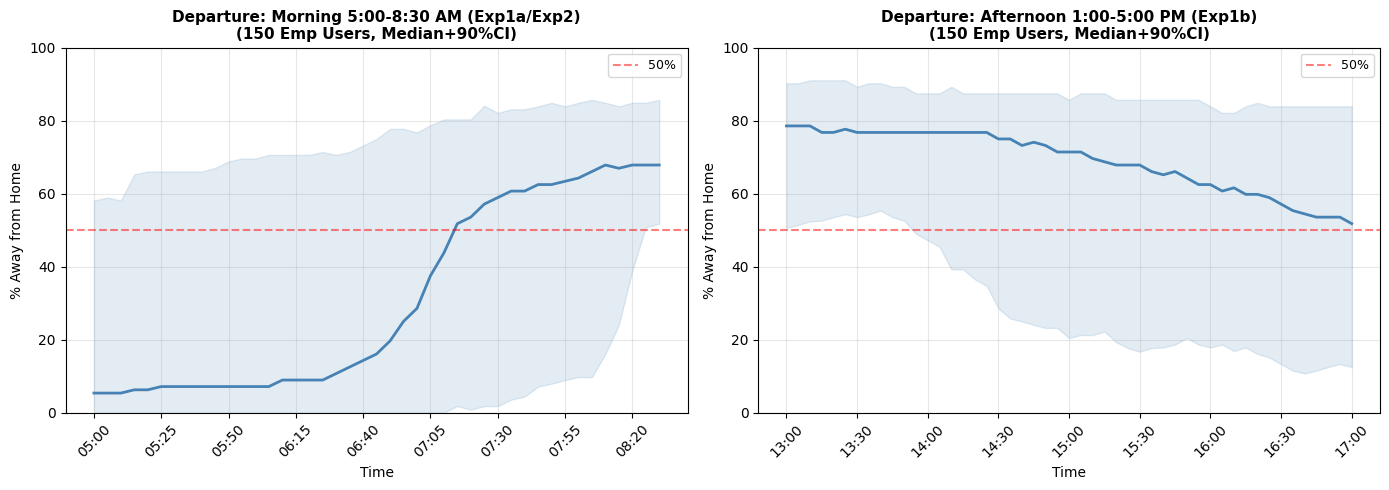

In [24]:
# === I1: Departure coverage by 5-min slot ===
exp1_data = df_traj[df_traj['in_exp1']].copy()
n_exp1 = exp1_data['cuebiq_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

windows = [
    (axes[0], 5*60, 8*60+30, 'Morning 5:00-8:30 AM (Exp1a/Exp2)'),
    (axes[1], 13*60, 17*60, 'Afternoon 1:00-5:00 PM (Exp1b)'),
]

for ax, start_min, end_min, title in windows:
    window = exp1_data[(exp1_data['hour']*60 + exp1_data['min5'] >= start_min) &
                        (exp1_data['hour']*60 + exp1_data['min5'] <= end_min)]
    # Per user per slot: fraction of days away
    us = (window.groupby(['cuebiq_id', 'hour', 'min5'])['is_at_home']
          .mean().reset_index())
    us['p_away'] = 1 - us['is_at_home']
    us['minutes'] = us['hour'] * 60 + us['min5']
    # Across users: median
    ss = (us.groupby('minutes')['p_away']
          .agg(median='median',
               ci_lo=lambda x: np.percentile(x, 5),
               ci_hi=lambda x: np.percentile(x, 95))
          .reset_index())
    labels = [f"{m//60:02d}:{m%60:02d}" for m in ss['minutes']]
    x = range(len(ss))
    ax.plot(x, ss['median']*100, '-', color='steelblue', lw=2)
    ax.fill_between(x, ss['ci_lo']*100, ss['ci_hi']*100, alpha=0.15, color='steelblue')
    ax.axhline(50, color='r', ls='--', alpha=0.5, label='50%')
    ax.set_title(f'Departure: {title}\n({n_exp1} Emp Users, Median+90%CI)', fontsize=11, fontweight='bold')
    ax.set_ylabel('% Away from Home'); ax.set_xlabel('Time')
    step = max(1, len(labels) // 8)
    ax.set_xticks(range(0, len(labels), step))
    ax.set_xticklabels([labels[i] for i in range(0, len(labels), step)], rotation=45)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{CONFIG['data_dir']}/coverage_reports.png", dpi=300, bbox_inches='tight')
plt.show()

## Section J: Final Summary

In [25]:
# === J1: Summary ===
print("=" * 60)
print("NEURAL MECHANICS V2 - DATA SUMMARY")
print("=" * 60)
print(f"Date range:       {CONFIG['date_start']} to {CONFIG['date_end']}")
print(f"Time granularity: 5-min intervals, forward-filled from raw GPS pings")
print(f"Grid:             {N_SLOTS} slots/day/user (uniform, no gaps)")
print(f"Total users:      {all_sampled['cuebiq_id'].nunique()}")
print(f"  Employed:       {(all_sampled['is_employed']==1).sum()}")
print(f"  Unemployed:     {(all_sampled['is_employed']==0).sum()}")
print(f"Trajectory rows:  {len(df_traj):,}")
print()
print("Experiment populations:")
print(f"  Exp1a/1b: {df_traj[df_traj['in_exp1']]['cuebiq_id'].nunique()} employed users")
print(f"  Exp2:     {len(all_sampled)} users (150+150)")
print()
print("Forward fill method:")
print("  Each 5-min slot = geo_id of most recent GPS ping at or before that time.")
print("  No ping before slot -> user assumed at home.")
print("  Result: every user-day has exactly 288 rows.")
print()
print("Files:")
for fpath in [CONFIG['users_file'], CONFIG['traj_processed_file'], CONFIG.get('coords_file','')]:
    if fpath and os.path.exists(fpath):
        sz = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {fpath} ({sz:.1f} MB)")
print()
print("Ready for V2 pipeline.")

NEURAL MECHANICS V2 - DATA SUMMARY
Date range:       2020-01-06 to 2020-03-01
Time granularity: 5-min intervals, forward-filled from raw GPS pings
Grid:             288 slots/day/user (uniform, no gaps)
Total users:      300
  Employed:       150
  Unemployed:     150
Trajectory rows:  4,838,400

Experiment populations:
  Exp1a/1b: 150 employed users
  Exp2:     300 users (150+150)

Forward fill method:
  Each 5-min slot = geo_id of most recent GPS ping at or before that time.
  No ping before slot -> user assumed at home.
  Result: every user-day has exactly 288 rows.

Files:
  ./data/users.csv (0.0 MB)
  ./data/trajectories_processed.csv (678.4 MB)
  ./data/trajectories_with_coords.csv (38.8 MB)

Ready for V2 pipeline.


In [3]:
# === Trim to 120 emp + 120 unemp ===
import pandas as pd
import numpy as np
import os

np.random.seed(42)

# Load
users = pd.read_csv('./data/users.csv')
df = pd.read_csv('./data/trajectories_processed.csv', low_memory=False)

# Sample 120 from each side
emp_ids = users[users['is_employed'] == 1]['cuebiq_id'].values
unemp_ids = users[users['is_employed'] == 0]['cuebiq_id'].values
keep_emp = np.random.choice(emp_ids, 120, replace=False)
keep_unemp = np.random.choice(unemp_ids, 120, replace=False)
keep_all = set(keep_emp) | set(keep_unemp)

print(f"Keeping: {len(keep_emp)} emp + {len(keep_unemp)} unemp = {len(keep_all)} total")

# Rename old, save new
os.rename('./data/trajectories_processed.csv', './data/trajectories_processed_150_for_each.csv')
df_trimmed = df[df['cuebiq_id'].isin(keep_all)]
df_trimmed.to_csv('./data/trajectories_processed.csv', index=False)

# Also update users.csv
os.rename('./data/users.csv', './data/users_150_for_each.csv')
users_trimmed = users[users['cuebiq_id'].isin(keep_all)].copy()
users_trimmed['in_exp1'] = users_trimmed['is_employed'] == 1
users_trimmed['in_exp2'] = True
users_trimmed.to_csv('./data/users.csv', index=False)

print(f"Old: {len(df):,} rows → New: {len(df_trimmed):,} rows")
print(f"Old: {len(users)} users → New: {len(users_trimmed)} users")
print(f"Saved: trajectories_processed.csv ({len(df_trimmed):,} rows, {len(keep_all)} users)")

Keeping: 120 emp + 120 unemp = 240 total
Old: 4,838,400 rows → New: 3,870,720 rows
Old: 300 users → New: 240 users
Saved: trajectories_processed.csv (3,870,720 rows, 240 users)


In [14]:
# #os.remove('./data/trajectories_with_coords.csv')


# run below code on local
# # === H0-v2: Query coords for EXACTLY the 240 trimmed users ===
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Force re-query
# COORDS_FILE = './data/trajectories_with_coords_240.csv'

# users_240 = pd.read_csv('./data/users.csv')
# print(f"Users: {len(users_240)} ({(users_240['is_employed']==1).sum()} emp + "
#       f"{(users_240['is_employed']==0).sum()} unemp)")

# if os.path.exists(COORDS_FILE):
#     df_coords = pd.read_csv(COORDS_FILE)
# else:
#     user_list = ",".join([f"'{u}'" for u in users_240['cuebiq_id']])
#     q = (
#         "SELECT cuebiq_id, DATE(ts_local) as date,"
#         " EXTRACT(HOUR FROM ts_local) as hour,"
#         " EXTRACT(DAYOFWEEK FROM ts_local) as dow,"
#         " AVG(ST_Y(geopoint)) as lat, AVG(ST_X(geopoint)) as lng,"
#         " COUNT(*) as n_pings"
#         " FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`"
#         f" WHERE DATE(ts_local) BETWEEN '{CONFIG['date_start']}' AND '{CONFIG['date_end']}'"
#         f" AND cuebiq_id IN ({user_list})"
#         " GROUP BY cuebiq_id, date, hour, dow"
#         " ORDER BY cuebiq_id, date, hour"
#     )
#     print("Querying BQ for 240 users...")
#     df_coords = client.query(q).to_dataframe()
#     df_coords.to_csv(COORDS_FILE, index=False)
#     print(f"Saved: {COORDS_FILE}")

# df_coords['date'] = df_coords['date'].astype(str)
# emp_lookup = users_240.set_index('cuebiq_id')['is_employed'].to_dict()
# exp1_lookup = users_240.set_index('cuebiq_id')['in_exp1'].to_dict()

# df_coords['is_employed'] = df_coords['cuebiq_id'].map(emp_lookup)
# df_coords['is_weekend'] = df_coords['dow'].isin([1, 7]).astype(int)
# df_coords['is_weekday'] = 1 - df_coords['is_weekend']
# df_coords['is_holiday'] = df_coords['date'].isin(CONFIG['holidays']).astype(int)
# df_coords['in_exp1'] = df_coords['cuebiq_id'].map(exp1_lookup).fillna(False)

# home_pos = (df_coords[(df_coords['hour'].isin([0,1,2,3,4,5])) & (df_coords['is_weekday']==1)]
#             .groupby('cuebiq_id').agg({'lat':'median', 'lng':'median'})
#             .rename(columns={'lat':'home_lat', 'lng':'home_lng'}))
# df_coords = df_coords.merge(home_pos, on='cuebiq_id')
# df_coords['dist_km'] = np.sqrt((df_coords['lat']-df_coords['home_lat'])**2 +
#                                 (df_coords['lng']-df_coords['home_lng'])**2) * 111
# df_clean = df_coords[df_coords['dist_km'] < 111].copy()

# print(f"Result: {df_clean['cuebiq_id'].nunique()} users, {len(df_clean):,} rows")
# print(f"  Exp1 (employed): {df_clean[df_clean['in_exp1']==True]['cuebiq_id'].nunique()}")
# print(f"  Exp2 (all): {df_clean['cuebiq_id'].nunique()}")

In [15]:
# === H0-v2: Load coords and filter to trimmed 240 users ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Current 240 users
users_240 = pd.read_csv('./data/users.csv')
keep_ids = set(users_240['cuebiq_id'])
emp_lookup = users_240.set_index('cuebiq_id')['is_employed'].to_dict()
exp1_lookup = users_240.set_index('cuebiq_id')['in_exp1'].to_dict()

# Load full coords (300 users) and filter
df_coords = pd.read_csv('./data/trajectories_with_coords_240.csv')
df_coords = df_coords[df_coords['cuebiq_id'].isin(keep_ids)].copy()
df_coords['date'] = df_coords['date'].astype(str)

# Add labels
df_coords['is_employed'] = df_coords['cuebiq_id'].map(emp_lookup)
df_coords['is_weekend'] = df_coords['dow'].isin([1, 7]).astype(int)
df_coords['is_weekday'] = 1 - df_coords['is_weekend']
df_coords['is_holiday'] = df_coords['date'].isin(CONFIG['holidays']).astype(int)
df_coords['in_exp1'] = df_coords['cuebiq_id'].map(exp1_lookup).fillna(False)

# Home = median position during weekday 0-5am
home_pos = (df_coords[(df_coords['hour'].isin([0,1,2,3,4,5])) & (df_coords['is_weekday']==1)]
            .groupby('cuebiq_id').agg({'lat':'median', 'lng':'median'})
            .rename(columns={'lat':'home_lat', 'lng':'home_lng'}))
df_coords = df_coords.merge(home_pos, on='cuebiq_id')
df_coords['dist_km'] = np.sqrt((df_coords['lat']-df_coords['home_lat'])**2 +
                                (df_coords['lng']-df_coords['home_lng'])**2) * 111
df_clean = df_coords[df_coords['dist_km'] < 111].copy()

print(f"Filtered to 240 users: {df_clean['cuebiq_id'].nunique()} users, {len(df_clean):,} rows")
print(f"  Exp1 (employed): {df_clean[df_clean['in_exp1']==True]['cuebiq_id'].nunique()}")
print(f"  Outliers removed: {len(df_coords)-len(df_clean)}")

Filtered to 240 users: 240 users, 285,278 rows
  Exp1 (employed): 120
  Outliers removed: 10768


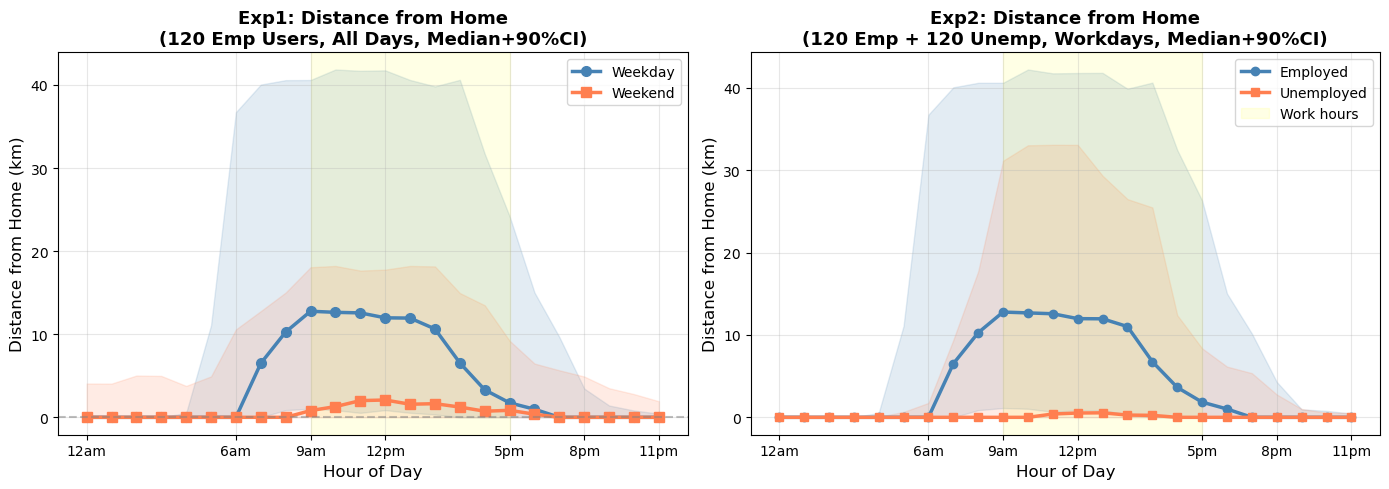

Saved: distance_panels_240.png/.pdf (120 emp for Exp1, 120+120 for Exp2)


In [16]:
# === H2-v2: Distance panels (240 users) ===
def compute_dist_stats(data, group_col, group_vals, time_col='hour'):
    results = {}
    for val, label in group_vals:
        subset = data[data[group_col] == val]
        user_hour = subset.groupby(['cuebiq_id', time_col])['dist_km'].median().reset_index()
        stats = (user_hour.groupby(time_col)['dist_km']
                 .agg(median='median',
                      ci_lo=lambda x: np.percentile(x, 5),
                      ci_hi=lambda x: np.percentile(x, 95))
                 .reset_index())
        results[label] = stats
    return results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Exp1 Weekday vs Weekend (120 employed, all days)
d1 = df_clean[df_clean['in_exp1'] == True]
n1 = d1['cuebiq_id'].nunique()
s1 = compute_dist_stats(d1, 'is_weekday', [(1, 'Weekday'), (0, 'Weekend')])

ax = axes[0]
for label, color, mk in [('Weekday', 'steelblue', 'o'), ('Weekend', 'coral', 's')]:
    s = s1[label]
    ax.plot(s['hour'], s['median'], f'{mk}-', label=label, color=color, lw=2.5, ms=7)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvspan(9, 17, alpha=0.1, color='yellow')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
ax.set_title(f'Exp1: Distance from Home\n({n1} Emp Users, All Days, Median+90%CI)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

# Panel 2: Exp2 Employed vs Unemployed (240 users, workdays)
d2 = df_clean[(df_clean['is_weekday']==1) & (df_clean['is_holiday']==0)]
ne = d2[d2['is_employed']==1]['cuebiq_id'].nunique()
nu = d2[d2['is_employed']==0]['cuebiq_id'].nunique()
s2 = compute_dist_stats(d2, 'is_employed', [(1, 'Employed'), (0, 'Unemployed')])

ax = axes[1]
for label, color, mk in [('Employed', 'steelblue', 'o'), ('Unemployed', 'coral', 's')]:
    s = s2[label]
    ax.plot(s['hour'], s['median'], f'{mk}-', label=label, color=color, lw=2.5, ms=6)
    ax.fill_between(s['hour'], s['ci_lo'], s['ci_hi'], alpha=0.15, color=color)
ax.axvspan(9, 17, alpha=0.1, color='yellow', label='Work hours')
ax.set_title(f'Exp2: Distance from Home\n({ne} Emp + {nu} Unemp, Workdays, Median+90%CI)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

for ax in axes:
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Distance from Home (km)', fontsize=12)
    ax.set_xticks([0, 6, 9, 12, 17, 20, 23])
    ax.set_xticklabels(['12am', '6am', '9am', '12pm', '5pm', '8pm', '11pm'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/distance_panels_240.png', dpi=600, bbox_inches='tight')
plt.savefig('./data/distance_panels_240.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: distance_panels_240.png/.pdf ({n1} emp for Exp1, {ne}+{nu} for Exp2)")

In [2]:
import numpy as np
import pandas as pd

fp_v7 = "/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7/gemma-4-31B-it-unsloth-bnb-4bit/outputs_v7/per_user/1b7b40d1f80dea0523742d84091399e09f588304e7271e8ae41c45dd01064114.npz"
fp_v8 = "/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7/gemma-4-31B-it-unsloth-bnb-4bit/outputs_v8/per_user/1b7b40d1f80dea0523742d84091399e09f588304e7271e8ae41c45dd01064114.npz"

def build_length_df(fp, tag):
    data = np.load(fp, allow_pickle=True)
    meta = data["meta"]
    answers = data["answers"]

    rows = []
    for i, (m, a) in enumerate(zip(meta, answers)):
        rows.append({
            "iter": tag,
            "idx": i,
            "exp_name": m.get("exp_name"),
            "config_id": m.get("config_id"),
            "date": m.get("date"),
            "pred_time": m.get("pred_time"),
            "gt_geo_id": m.get("gt_geo_id"),
            "parsed_answer": a.get("parsed_answer"),
            "status": a.get("status"),
            "n_tokens": a.get("n_tokens"),
            "char_len": len(a.get("generated_text", "")),
        })
    return pd.DataFrame(rows)

df_v7 = build_length_df(fp_v7, "v7")
df_v8 = build_length_df(fp_v8, "v8")
df = pd.concat([df_v7, df_v8], ignore_index=True)

print("=== Summary of n_tokens ===")
print(df["n_tokens"].describe())

print("\n=== Max n_tokens rows ===")
display(df.sort_values("n_tokens", ascending=False).head(20))

print("\n=== Rows with n_tokens >= 2048 ===")
display(df[df["n_tokens"] >= 2048].sort_values("n_tokens", ascending=False))

print("\n=== Rows with n_tokens between 1800 and 2048 ===")
display(df[(df["n_tokens"] >= 1800) & (df["n_tokens"] < 2048)].sort_values("n_tokens", ascending=False))

=== Summary of n_tokens ===
count      64.000000
mean     4861.890625
std       947.611921
min      3472.000000
25%      4204.000000
50%      4733.500000
75%      5709.500000
max      6909.000000
Name: n_tokens, dtype: float64

=== Max n_tokens rows ===


,iter,idx,exp_name,config_id,date,pred_time,gt_geo_id,parsed_answer,status,n_tokens,char_len
23,v7,23,exp2,4,2020-01-24,17:00,250056501013,250056501013,ok,6909,1528
52,v8,20,exp2,4,2020-02-05,12:00,250056519001,250056502012,ok,6655,1701
20,v7,20,exp2,4,2020-02-05,12:00,250056519001,250056502012,ok,6636,2681
53,v8,21,exp2,4,2020-02-05,17:00,250056501013,250056501013,ok,6624,1952
21,v7,21,exp2,4,2020-02-05,17:00,250056501013,250056501013,ok,6605,1760
55,v8,23,exp2,4,2020-02-12,17:00,250056501013,250056501013,ok,6376,1469
22,v7,22,exp2,4,2020-01-24,12:00,250056508003,250056508003,ok,6244,1740
31,v7,31,exp2,8,2020-01-24,17:00,250056501013,7afc8338,ok,5975,2218
19,v7,19,exp2,2,2020-01-24,17:00,250056501013,250056501013,ok,5971,2046
54,v8,22,exp2,4,2020-02-12,12:00,250056502012,250056519001,ok,5841,1884



=== Rows with n_tokens >= 2048 ===


,iter,idx,exp_name,config_id,date,pred_time,gt_geo_id,parsed_answer,status,n_tokens,char_len
23,v7,23,exp2,4,2020-01-24,17:00,250056501013,250056501013,ok,6909,1528
52,v8,20,exp2,4,2020-02-05,12:00,250056519001,250056502012,ok,6655,1701
20,v7,20,exp2,4,2020-02-05,12:00,250056519001,250056502012,ok,6636,2681
53,v8,21,exp2,4,2020-02-05,17:00,250056501013,250056501013,ok,6624,1952
21,v7,21,exp2,4,2020-02-05,17:00,250056501013,250056501013,ok,6605,1760
...,...,...,...,...,...,...,...,...,...,...,...
13,v7,13,exp1a,4,2020-01-27,17:00,250056502012,b3b63626,ok,3598,2177
44,v8,12,exp1a,4,2020-02-20,12:00,250056508003,2e2f9c8e,ok,3583,1254
43,v8,11,exp1a,4,2020-01-26,17:00,250056501013,7afc8338,ok,3525,2884
40,v8,8,exp1a,4,2020-01-21,12:00,250056508003,2e2f9c8e,ok,3522,1275



=== Rows with n_tokens between 1800 and 2048 ===


,iter,idx,exp_name,config_id,date,pred_time,gt_geo_id,parsed_answer,status,n_tokens,char_len


In [3]:
import numpy as np
from transformers import AutoTokenizer

model_path = "/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7/gemma-4-31B-it-unsloth-bnb-4bit"
fp_v7 = "/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7/gemma-4-31B-it-unsloth-bnb-4bit/outputs_v7/per_user/1b7b40d1f80dea0523742d84091399e09f588304e7271e8ae41c45dd01064114.npz"
fp_v8 = "/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7/gemma-4-31B-it-unsloth-bnb-4bit/outputs_v8/per_user/1b7b40d1f80dea0523742d84091399e09f588304e7271e8ae41c45dd01064114.npz"

MAX_NEW_TOKENS_COT_GEMMA4 = 2048
NEAR_MARGIN = 200

tokenizer = AutoTokenizer.from_pretrained(model_path)

def print_long_generated(fp, tag):
    data = np.load(fp, allow_pickle=True)
    meta = data["meta"]
    answers = data["answers"]

    print(f"\n{'='*120}")
    print(f"{tag}")
    print(f"{'='*120}")

    for i, (m, a) in enumerate(zip(meta, answers)):
        text = a.get("generated_text", "")
        gen_len = len(tokenizer.encode(text, add_special_tokens=False))

        if gen_len > MAX_NEW_TOKENS_COT_GEMMA4 or gen_len >= MAX_NEW_TOKENS_COT_GEMMA4 - NEAR_MARGIN:
            print(
                f"idx={i:2d} | exp={m['exp_name']} | cfg={m['config_id']} | "
                f"date={m['date']} | pred_time={m['pred_time']} | "
                f"generated_tok_len={gen_len} | stored_n_tokens={a.get('n_tokens')}"
            )

print_long_generated(fp_v7, "v7")
print_long_generated(fp_v8, "v8")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Exception: data did not match any variant of untagged enum ModelWrapper at line 2322063 column 3